# Data Downloading

## 1.Download data

In [3]:
from pathlib import Path
import random
import shutil

DEST = Path("../data")
RAW_DIR = Path("../data/_raw_kaggle")
KAGGLE_DATASET = "sayedgamal99/smoke-fire-detection-yolo"  # miroir YOLO de D-Fire
SPLIT_RATIO = [0.8, 0.1, 0.1]
SEED = 42
IMG_EXTS = {".jpg", ".jpeg", ".png"}


In [4]:
# Installation à la volée si besoin
try:
    import kagglehub
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "--break-system-packages", "-q", "kagglehub"], check=True)
    import kagglehub

print("Téléchargement depuis Kaggle...")
path = kagglehub.dataset_download(KAGGLE_DATASET)
print(f"Téléchargé dans : {path}")

RAW_DIR.mkdir(parents=True, exist_ok=True)
for item in Path(path).iterdir():
    target = RAW_DIR / item.name
    if not target.exists():
        if item.is_dir():
            shutil.copytree(item, target)
        else:
            shutil.copy2(item, target)
print(f"Copié dans : {RAW_DIR}")


Téléchargement depuis Kaggle...
Téléchargé dans : C:\Users\Neo\.cache\kagglehub\datasets\sayedgamal99\smoke-fire-detection-yolo\versions\1
Copié dans : ..\data\_raw_kaggle


## 2.Organisation

In [8]:
def already_split(raw_dir):
    return any((raw_dir.parent / "images" / s).exists() for s in ["train", "val", "test"])

def find_image_label_pairs(raw_dir):
    pairs = []
    for img_path in raw_dir.rglob("*"):
        if img_path.suffix.lower() not in IMG_EXTS:
            continue
        candidates = [
            img_path.parent / f"{img_path.stem}.txt",
            img_path.parent.parent / "labels" / img_path.parent.name / f"{img_path.stem}.txt",
        ]
        label_path = next((c for c in candidates if c.exists()), None)
        if label_path is None:
            matches = list(raw_dir.rglob(f"{img_path.stem}.txt"))
            label_path = matches[0] if matches else None
        if label_path is not None:
            pairs.append((img_path, label_path))
    return pairs

def organize_pre_split(raw_dir, dest):
    for split in ["train", "val", "test"]:
        src_img, src_lbl = raw_dir / "images" / split, raw_dir / "labels" / split
        if not src_img.exists():
            continue
        dst_img, dst_lbl = dest / "images" / split, dest / "labels" / split
        dst_img.mkdir(parents=True, exist_ok=True)
        dst_lbl.mkdir(parents=True, exist_ok=True)
        for img in src_img.glob("*"):
            if img.suffix.lower() in IMG_EXTS:
                shutil.copy2(img, dst_img / img.name)
                lbl = src_lbl / f"{img.stem}.txt"
                if lbl.exists():
                    shutil.copy2(lbl, dst_lbl / lbl.name)
        print(f"  -> {split}: {len(list(dst_img.glob('*')))} images")

def organize_and_split(pairs, dest, ratios, seed):
    random.seed(seed)
    random.shuffle(pairs)
    n = len(pairs)
    n_train, n_val = int(n * ratios[0]), int(n * ratios[1])
    splits = {"train": pairs[:n_train], "val": pairs[n_train:n_train+n_val], "test": pairs[n_train+n_val:]}
    for split, split_pairs in splits.items():
        img_dir, lbl_dir = dest / "images" / split, dest / "labels" / split
        img_dir.mkdir(parents=True, exist_ok=True)
        lbl_dir.mkdir(parents=True, exist_ok=True)
        for img_path, label_path in split_pairs:
            shutil.copy2(img_path, img_dir / img_path.name)
            shutil.copy2(label_path, lbl_dir / f"{img_path.stem}.txt")
        print(f"  -> {split}: {len(split_pairs)} images")

print("Organisation du dataset...")
if already_split(RAW_DIR):
    print("Dataset déjà splitté détecté.")
    organize_pre_split(RAW_DIR, DEST)
else:
    print("Pas de split détecté, recherche des paires image/label...")
    pairs = find_image_label_pairs(RAW_DIR)
    print(f"{len(pairs)} paires trouvées.")
    organize_and_split(pairs, DEST, SPLIT_RATIO, SEED)

print("\nDataset prêt dans data/images/ et data/labels/")


Organisation du dataset...
Dataset déjà splitté détecté.

Dataset prêt dans data/images/ et data/labels/


## 4.Verifiaction

In [9]:
import cv2
import matplotlib.pyplot as plt

for split in ["train", "val", "test"]:
    img_dir = DEST / "images" / split
    n = len(list(img_dir.glob("*"))) if img_dir.exists() else 0
    print(f"{split:6s}: {n} images")

train : 17221 images
val   : 2152 images
test  : 2154 images


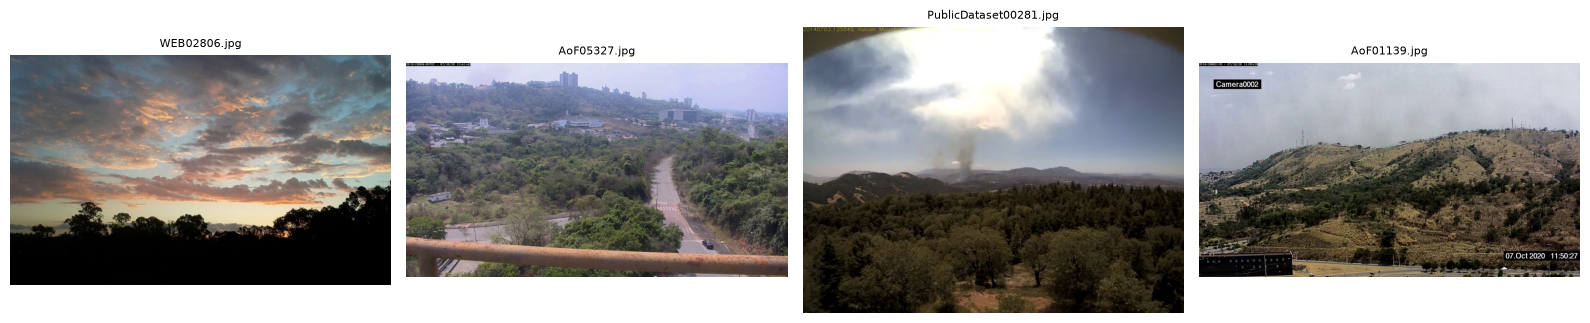


Pour une analyse complète des annotations (classes, tailles, positions), voir notebooks/01_eda_exploration.ipynb


In [11]:
# Aperçu de quelques images du split train pour confirmer visuellement que tout est cohérent
train_images = list((DEST / "images" / "train").glob("*"))
sample = random.sample(train_images, min(4, len(train_images)))

fig, axes = plt.subplots(1, len(sample), figsize=(16, 5))
axes = axes if len(sample) > 1 else [axes]
for img_path, ax in zip(sample, axes):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(img_path.name, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

print("\nPour une analyse complète des annotations (classes, tailles, positions), "
      "voir notebooks/01_eda_exploration.ipynb")